In [387]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from ppmi_utils import (
    cohort_map,
    event_id_to_visit,
    fields,
    load_ppmi_csvs,
    merge_ppmi_tables,
    numeric_fields,
    parse_imaging_protocol,
    plot_bar,
    plot_hist,
    primdiag_map,
    visit_to_event_id,
)

ROOT_DIR = Path(os.getcwd()).resolve().parents[1]
PPMI_CLINICAL = ROOT_DIR / "csv_dir" / "PPMI_CLINICAL"
PPMI_OTHERS = ROOT_DIR / "csv_dir" / "PPMI_OTHERS"
curated_data = PPMI_OTHERS / "PPMI_Curated_Data_Cut_Public_20251112.xlsx"
ppmi_imaging_descriptions_path = "/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_imaging_descriptions.json"
ppmi_imaging_ignored_path = "/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_imaging_ignored.csv"

# CSV preprocessing

### Uncurated clinical tabular data 

Not cureated, so might not be used unless missing info in the curated data need to be found here

In [388]:
ppmi_data = load_ppmi_csvs(PPMI_CLINICAL)
print(f"Available dataframes: {list(ppmi_data.keys())}")

Available dataframes: ['Participant_Status', 'MDS-UPDRS_Part_IV__Motor_Complications', 'Primary_Clinical_Diagnosis', 'MDS-UPDRS_Part_I', 'Symbol_Digit_Modalities_Test', 'MDS-UPDRS_Part_III', 'Montreal_Cognitive_Assessment__MoCA_', 'Clock_Drawing', 'Socio-Economics', 'Modified_Semantic_Fluency', 'Demographics', 'Modified_Boston_Naming_Test', 'MDS_UPDRS_Part_II__Patient_Questionnaire', 'Benton_Judgement_of_Line_Orientation', 'Clinical_Diagnosis', 'Letter_-_Number_Sequencing', 'Age_at_visit', 'MDS-UPDRS_Part_I_Patient_Questionnaire', 'University_of_Pennsylvania_Smell_Identification_Test_UPSIT']


In [389]:
uncurated_clinical_df = merge_ppmi_tables(ppmi_data)
print("Uncurated DataFrame shape:", uncurated_clinical_df.shape)
print("Uncurated DataFrame columns:", uncurated_clinical_df.columns.tolist())

Uncurated DataFrame shape: (54734, 461)
Uncurated DataFrame columns: ['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'NP4WDYSK', 'NP4WDYSKDEN', 'NP4WDYSKNUM', 'NP4WDYSKPCT', 'NP4DYSKI', 'NP4OFF', 'NP4OFFDEN', 'NP4OFFNUM', 'NP4OFFPCT', 'NP4FLCTI', 'NP4FLCTX', 'NP4DYSTN', 'NP4DYSTNDEN', 'NP4DYSTNNUM', 'NP4DYSTNPCT', 'NP4TOT', 'ORIG_ENTRY', 'LAST_UPDATE', 'REC_ID_Primary_Clinical_Diagnosis', 'PAG_NAME_Primary_Clinical_Diagnosis', 'INFODT_Primary_Clinical_Diagnosis', 'PRIMDIAG', 'NEWDIAGEXP', 'OTHNEURO', 'DXLVL', 'ORIG_ENTRY_Primary_Clinical_Diagnosis', 'LAST_UPDATE_Primary_Clinical_Diagnosis', 'REC_ID_MDS-UPDRS_Part_I', 'PAG_NAME_MDS-UPDRS_Part_I', 'INFODT_MDS-UPDRS_Part_I', 'NUPSOURC', 'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1RTOT', 'ORIG_ENTRY_MDS-UPDRS_Part_I', 'LAST_UPDATE_MDS-UPDRS_Part_I', 'REC_ID_Symbol_Digit_Modalities_Test', 'PAG_NAME_Symbol_Digit_Modalities_Test', 'INFODT_Symbol_Digit_Modalities_Test', 'SDMTOTAL', 'SDMTVRSN', 'AGE_ASSESS_SDM', 'D

### Official curated merge tabular data

In [390]:
curated_clinical_df = pd.read_excel(curated_data)
print("Curated Clinical DataFrame shape:", curated_clinical_df.shape)
print("Curated Clinical DataFrame columns:", curated_clinical_df.columns.tolist())

Curated Clinical DataFrame shape: (17252, 179)
Curated Clinical DataFrame columns: ['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'enroll_source', 'analytic_subgroup', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG', 'OTHNEURO', 'EVENT_ID', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_RECOG_DISC_INDEX', 'lexical', 'DVT_FAS', 'DVS_FAS', 'l

### idaSearch (image info)

In [391]:
# ida search csv load and preprocessing
ida_df = pd.read_csv(PPMI_OTHERS / "idaSearch_18Feb2026.csv", low_memory=False)
ida_df = ida_df[~ida_df["Modality"].isin(["Path", "CT"])].copy()
ida_df["Weight"] = ida_df["Weight"].replace(0, np.nan)
ida_df["Age"] = ida_df["Age"].replace(0, np.nan)
ida_df["Study Date"] = pd.to_datetime(ida_df["Study Date"], errors="coerce")
ida_df = ida_df.rename(columns={"Subject ID": "PATNO"})
protocol_parsed = ida_df["Imaging Protocol"].apply(parse_imaging_protocol)
for field in fields:
    ida_df[field] = protocol_parsed.apply(lambda x: x.get(field, np.nan))
for field in numeric_fields:
    ida_df[field] = pd.to_numeric(ida_df[field], errors="coerce")

# avanced modalities
with open(ppmi_imaging_descriptions_path, "r") as f:
    modality_dict = json.load(f)


def normalize_list(lst):
    return [s.strip().upper() for s in lst]


dwi_set = set(normalize_list(modality_dict["dwi"]))
func_set = set(normalize_list(modality_dict["func"]))
anat_sets = {k: set(normalize_list(v)) for k, v in modality_dict["anat"].items()}
ignore_df = pd.read_csv(ppmi_imaging_ignored_path)
ignore_set = set(ignore_df["Description"].str.strip().str.upper())
ida_df["Description_clean"] = ida_df["Description"].astype(str).str.strip().str.upper()
ida_df = ida_df[~ida_df["Description_clean"].isin(ignore_set)].copy()


def classify_advanced(row):
    desc = row["Description_clean"]
    modality = row["Modality"]
    # --- DWI ---
    if desc in dwi_set:
        return "DWI"
    # --- Functional ---
    if desc in func_set:
        return "rsfMRI"
    # --- Anatomical ---
    for anat_type, anat_set in anat_sets.items():
        if desc in anat_set:
            return anat_type  # T1w, T2w, T2starw, FLAIR
    # --- Nuclear imaging ---
    if modality == "PET":
        return "PET"
    if modality == "SPECT":
        return "SPECT"
    # --- fallback ---
    if modality == "MRI":
        return "MRI_other"
    if modality == "fMRI":
        return "fMRI_other"
    return "Unknown"


ida_df["Advanced_Modality"] = ida_df.apply(classify_advanced, axis=1)

# print(ida_df["Advanced_Modality"].value_counts())
# print(pd.crosstab(ida_df["Modality"], ida_df["Advanced_Modality"]))
print("ida searchDataFrame shape:", ida_df.shape)
print(ida_df.columns.tolist())

ida searchDataFrame shape: (80507, 30)
['PATNO', 'Project', 'Sex', 'Weight', 'Research Group', 'Visit', 'Study Date', 'Archive Date', 'Age', 'GDSCALE Total Score', 'Modality', 'Description', 'Type', 'Imaging Protocol', 'Image ID', 'Structure', 'Laterality', 'Image Type', 'Registration', 'Tissue', 'Acquisition Plane', 'Slice Thickness', 'Matrix Z', 'Acquisition Type', 'Manufacturer', 'Mfg Model', 'Field Strength', 'Weighting', 'Description_clean', 'Advanced_Modality']


### Merge clinical and imaging info

In [392]:
# merge clinical and imaging dataframes
ida_df["PATNO"] = ida_df["PATNO"].astype(str)
curated_clinical_df["PATNO"] = curated_clinical_df["PATNO"].astype(str)
ida_df["EVENT_ID"] = ida_df["Visit"].map(visit_to_event_id)
curated_clinical_df["PRIMDIAG_DESC"] = curated_clinical_df["PRIMDIAG"].map(primdiag_map)
curated_clinical_df["COHORT_DESC"] = curated_clinical_df["COHORT"].map(cohort_map)

cohort_map
df = pd.merge(
    curated_clinical_df,
    ida_df,
    # how="left",
    how="outer",
    on=["PATNO", "EVENT_ID"],
    suffixes=("", "_idasearch"),  # Curated stays same, Imaging gets '_ida' suffix
)
df["Visit"] = df["EVENT_ID"].map(event_id_to_visit)

print("Final merged DataFrame shape:", df.shape)
print("Final merged DataFrame columns:", df.columns.tolist())

/tmp/ipykernel_64407/1893907810.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  curated_clinical_df["PRIMDIAG_DESC"] = curated_clinical_df["PRIMDIAG"].map(primdiag_map)
/tmp/ipykernel_64407/1893907810.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  curated_clinical_df["COHORT_DESC"] = curated_clinical_df["COHORT"].map(cohort_map)


Final merged DataFrame shape: (91617, 210)
Final merged DataFrame columns: ['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'enroll_source', 'analytic_subgroup', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG', 'OTHNEURO', 'EVENT_ID', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_RECOG_DISC_INDEX', 'lexical', 'DVT_FAS', 'DVS_FAS', 'lns', 'DV

In [393]:
# patient_ex = df[(df["PATNO"] == "100445") & (df["EVENT_ID"] == "BL")].copy()
# print(patient_ex.shape)
# patient_ex.to_csv("patient_ex.csv", index=False)

# Filters

filter out

In [394]:
# general filters
print("Before filter:")
print("Shape ", df.shape)
print("unique patient ", df["PATNO"].nunique())
print("unique patient-visit pairs ", df.groupby(["PATNO", "EVENT_ID"]).ngroups)

df.groupby(["PATNO", "EVENT_ID"]).ngroups
df = df[df["EVENT_ID"].notna()].copy()  # only keep rows with valid event_id
df = df[df["Research Group"] != "Phantom"].copy()  # remove phantom scans
df = df[df["Image ID"].notna()].copy()  # only keep rows with imaging data

# filters on images
df = df[
    # (df["Advanced_Modality"].isin(["DWI"]))
    (df["Modality"].isin(["DTI"]))
    # (df["Advanced_Modality"].isin(["T1w", "FLAIR"]))
    # & (df["Acquisition Type"] == "3D")
    # & (df["Weighting"] == "T1")
    # & (df["Field Strength"] > 1.4)
    # & (df["Matrix Z"] > 100)
    # & (df["Slice Thickness"] < 1.4)
].copy()

# print(
#     f"Filtered dataset size: {df.shape[0]} images from {df['PATNO'].nunique()} subjects."
# )
# # save as csv for further exploration
# df.to_csv("ppmi_clinical_imaging_merged_filtered.csv", index=False)

print("After filter:")
print("Shape ", df.shape)
print("unique patient ", df["PATNO"].nunique())
print("unique patient-visit pairs ", df.groupby(["PATNO", "EVENT_ID"]).ngroups)

Before filter:
Shape  (91617, 210)
unique patient  5696
unique patient-visit pairs  20551
After filter:
Shape  (29369, 210)
unique patient  1977
unique patient-visit pairs  3393


In [395]:
# print percetage of na values in each column in the following list
col_list = ["PRIMDIAG", "COHORT", "Research Group", "subgroup", "Image ID"]
for col in col_list:
    na_percentage = df[col].isna().mean() * 100
    print(f"{col}: {na_percentage:.2f}% NA values")

PRIMDIAG: 2.39% NA values
COHORT: 2.22% NA values
Research Group: 0.00% NA values
subgroup: 2.22% NA values
Image ID: 0.00% NA values


# Basic analysis

### Patients and visits without images

In [396]:
# Visits without image ID
df_no_image_id = df[df["Image ID"].isna()]
n_visits_no_image = df_no_image_id.groupby(["PATNO", "EVENT_ID"]).ngroups
print(f"Number of visits without 'Image ID': {n_visits_no_image}")

total_visits = df.groupby(["PATNO", "EVENT_ID"]).ngroups
print(f"Total number of visits: {total_visits}")
print(
    f"Percentage of visits without 'Image ID': {n_visits_no_image / total_visits:.2%}"
)

Number of visits without 'Image ID': 0
Total number of visits: 3393
Percentage of visits without 'Image ID': 0.00%


In [397]:
# Number of unique patients with at least one visit without image ID
# Total number of patients
total_patients = df["PATNO"].nunique()
# Number of patients with no images at all
patients_with_image = df.loc[df["Image ID"].notna(), "PATNO"].unique()
patients_no_image = set(df["PATNO"]) - set(patients_with_image)
n_patients_no_image = len(patients_no_image)

print(f"Total patients: {total_patients}")
print(f"Patients with no image at all: {n_patients_no_image}")
print(f"Percentage with no image: {n_patients_no_image / total_patients:.2%}")


Total patients: 1977
Patients with no image at all: 0
Percentage with no image: 0.00%


### Age at baseline

Baseline age summary (one row per patient):
      count       mean       std        min        25%        50%        75%  \
age  1750.0  65.299762  8.432568  30.410959  61.184247  65.883562  70.799315   

           max  
age  85.876712  


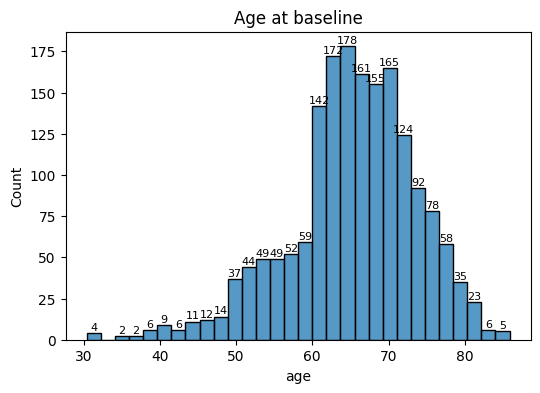

In [398]:
baseline_df = df[df["EVENT_ID"] == "BL"].copy()
baseline_unique = baseline_df.drop_duplicates(subset=["PATNO"])  # keep first occurence
print("Baseline age summary (one row per patient):")
print(baseline_unique[["age"]].describe().T)
plot_hist(baseline_unique, "age", title="Age at baseline")

### Sex distribution

Sex distribution at baseline:
Sex       M    F
count  1028  754


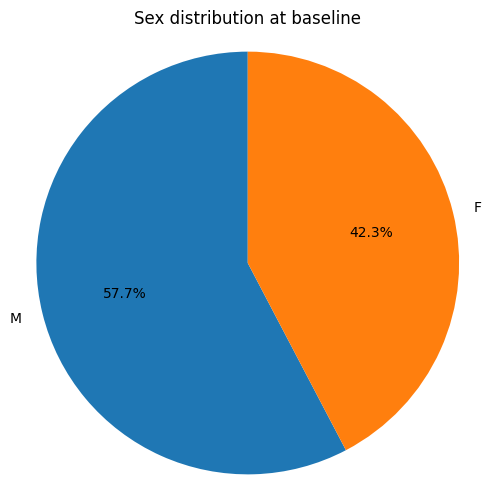

In [399]:
# Count occurrences
sex_counts = baseline_unique["Sex"].value_counts()

# Print table
print("Sex distribution at baseline:")
print(sex_counts.to_frame().T)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.1f%%",  # show percentage
    startangle=90,  # rotate to start from top
)
plt.title("Sex distribution at baseline")
plt.axis("equal")  # equal aspect ratio ensures pie is circular
plt.show()


### Cohort definition
1. Parkinson’s Disease, i.e., people who have a formal diagnosis of Parkinson’s disease (PD) 
2. Prodromal, i.e., people who are at risk of developing PD based on clinical features, genetic variants or other biomarkers but have not been formally diagnosed 
3. Healthy Controls, i.e., people with no neurologic disorder and no first-degree relative with PD
4. SWEDD (Scan without dopaminergic deficit). This is a small legacy cohort that you may wish to exclude, depending on your research purpose; for more details, see https://www.ppmi-info.org/study-design/study-cohorts#legacy/

Diagnosis distribution at baseline:


/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


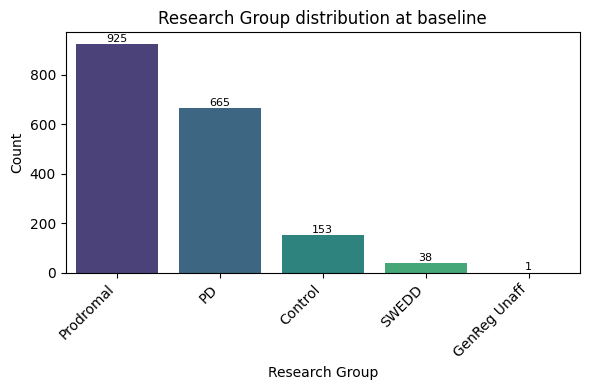

In [400]:
# diagnosis at baseline
print("Diagnosis distribution at baseline:")
cohort_counts = baseline_unique["Research Group"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "Research Group",
    title="Research Group distribution at baseline",
)

/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


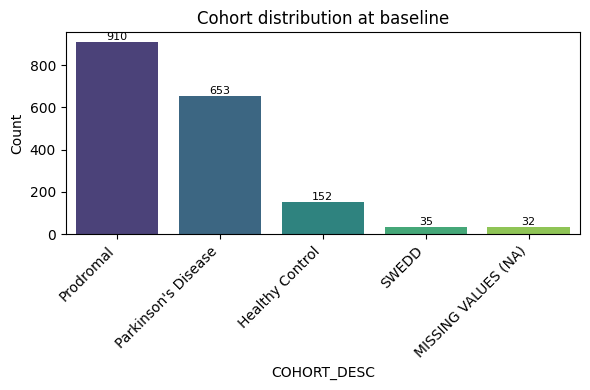

In [401]:
cohort_counts = baseline_unique["COHORT_DESC"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "COHORT_DESC",
    title="Cohort distribution at baseline",
)

### subgroup
Subgroup is derived from various source columns to give a more detailed group assignment than cohort. It can take values of Healthy Control, SWEDD, SWEDD/PD, SWEDD/nonPD, Hyposmia, RBD, Sporadic PD, LRRK2, GBA, PINK1, PRKN, SNCA or combinations of genetic variants and/or RBD (e.g. LRRK2 + GBA, GBA + RBD).

/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


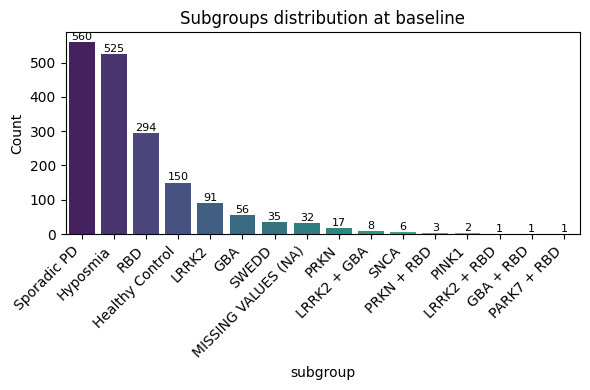

In [402]:
cohort_counts = baseline_unique["subgroup"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "subgroup",
    title="Subgroups distribution at baseline",
)

### PRIMDIAG

/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


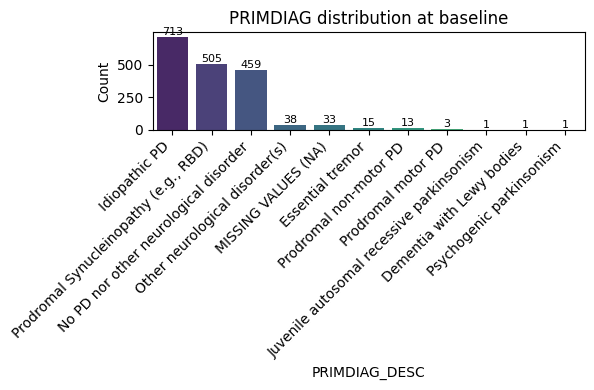

In [403]:
cohort_counts = baseline_unique["PRIMDIAG_DESC"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "PRIMDIAG_DESC",
    title="PRIMDIAG distribution at baseline",
)

# Longitudinal analysis

### Cumulative number of visits through years

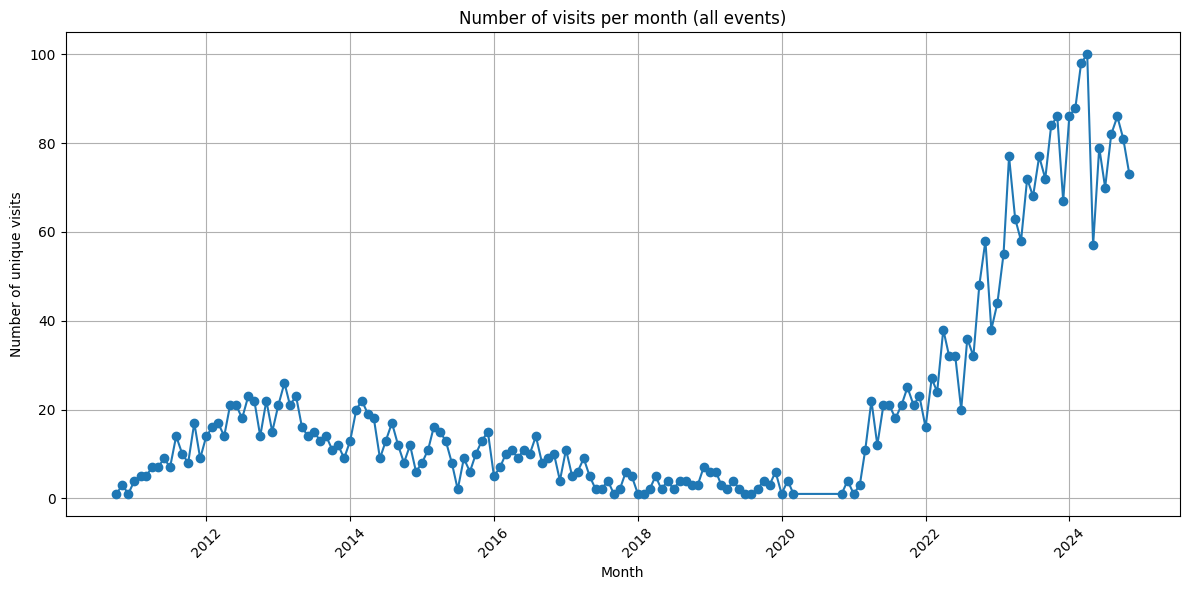

In [404]:
# Ensure Study Date is datetime
df["Study Date"] = pd.to_datetime(df["Study Date"], errors="coerce")

# Keep only unique patient-event pairs
unique_visits = df.drop_duplicates(subset=["PATNO", "EVENT_ID"])
unique_visits = unique_visits[unique_visits["Study Date"] >= "2010-01-01"]
unique_visits["YearMonth"] = unique_visits["Study Date"].dt.to_period("M")
visits_per_month = unique_visits.groupby("YearMonth").size()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(visits_per_month.index.to_timestamp(), visits_per_month.values, marker="o")
plt.title("Number of visits per month (all events)")
plt.xlabel("Month")
plt.ylabel("Number of unique visits")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### How many visits per patient ?

Visits per patient (summary):
           count      mean       std  min  25%  50%  75%  max
EVENT_ID  1977.0  1.716237  0.895278  1.0  1.0  1.0  2.0  5.0


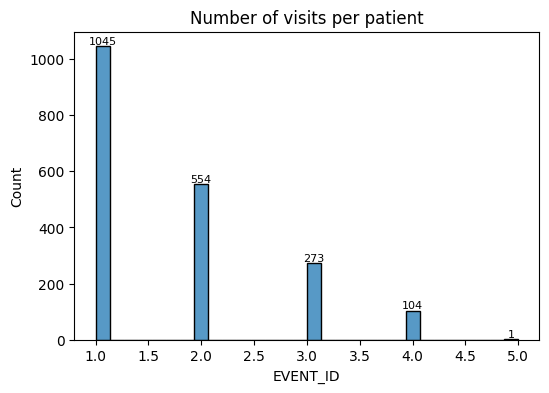

In [405]:
visits_per_patient = df.groupby("PATNO")["EVENT_ID"].nunique()
print("Visits per patient (summary):")
print(visits_per_patient.describe().to_frame().T)
# Histogram of visit counts
plot_hist(
    visits_per_patient.reset_index(), "EVENT_ID", title="Number of visits per patient"
)

### Longitudinal diagnosis changes

There is no change for 
column_name_for_transition = "COHORT_DESC"
column_name_for_transition = "Research Group"

Number of patients with diagnosis change: 139


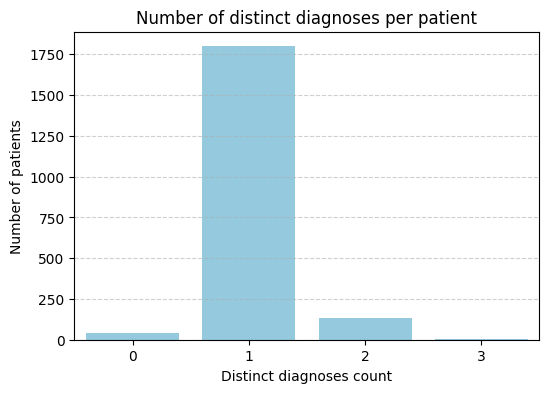

In [406]:
column_name_for_transition = "PRIMDIAG_DESC"

# number of distinct diagnoses per patient
diagnosis_over_time = df.groupby("PATNO")[column_name_for_transition].nunique()

# Patients with >1 diagnosis
patients_changed_diag = diagnosis_over_time[diagnosis_over_time > 1]
print(f"Number of patients with diagnosis change: {len(patients_changed_diag)}")

# diagnosis_per_patient = df.groupby("PATNO")[column_name].unique()
# for pat in patients_changed_diag.index:
#     print(f"{pat}: {diagnosis_per_patient[pat]}")

# Plot distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=diagnosis_over_time, color="skyblue")
plt.title("Number of distinct diagnoses per patient")
plt.xlabel("Distinct diagnoses count")
plt.ylabel("Number of patients")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

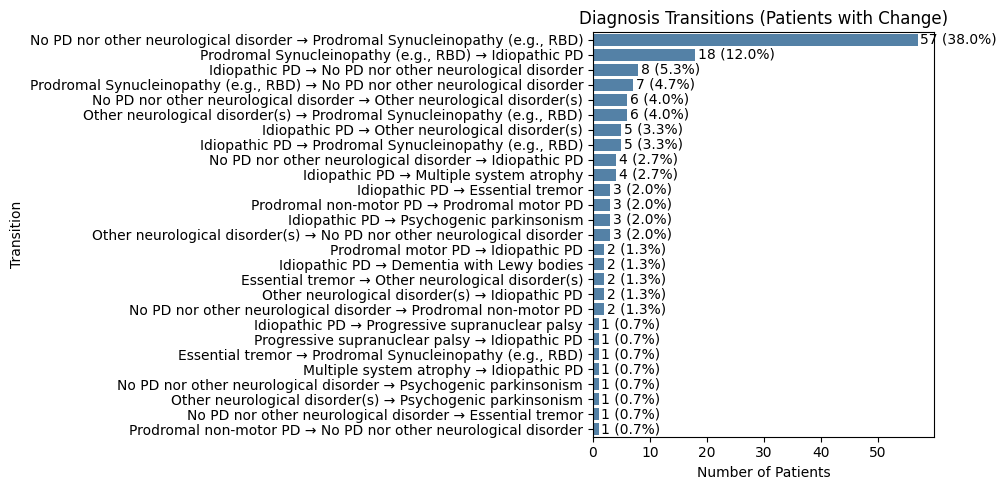

In [407]:
# Ensure visits are ordered in time
df_sorted = df.sort_values(["PATNO", "Study Date"])

transitions = []

for pat, group in df_sorted.groupby("PATNO"):
    diagnoses = group[column_name_for_transition].dropna().unique()

    if len(diagnoses) > 1:
        # Get ordered diagnoses per visit (not just unique)
        ordered_diag = (
            group[[column_name_for_transition, "Study Date"]]
            .dropna()
            .sort_values("Study Date")[column_name_for_transition]
            .tolist()
        )

        # Remove consecutive duplicates
        cleaned = [ordered_diag[0]]
        for d in ordered_diag[1:]:
            if d != cleaned[-1]:
                cleaned.append(d)

        # Create pairwise transitions
        for i in range(len(cleaned) - 1):
            transitions.append(f"{cleaned[i]} → {cleaned[i + 1]}")


transition_counts = pd.Series(transitions).value_counts()

# Total number of transitions
total_transitions = transition_counts.sum()

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=transition_counts.values, y=transition_counts.index, color="steelblue"
)

plt.title("Diagnosis Transitions (Patients with Change)")
plt.xlabel("Number of Patients")
plt.ylabel("Transition")

# Annotate with count + percentage
for i, (count, label) in enumerate(
    zip(transition_counts.values, transition_counts.index)
):
    percentage = 100 * count / total_transitions
    ax.text(
        count + 0.5,  # position slightly to the right of bar
        i,
        f"{count} ({percentage:.1f}%)",
        va="center",
    )

plt.tight_layout()
plt.show()


# print("Transition counts:")
# print(transition_counts)

### Retention

/tmp/ipykernel_64407/2053750222.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[visite_date_column] = pd.to_datetime(df[visite_date_column], errors="coerce")


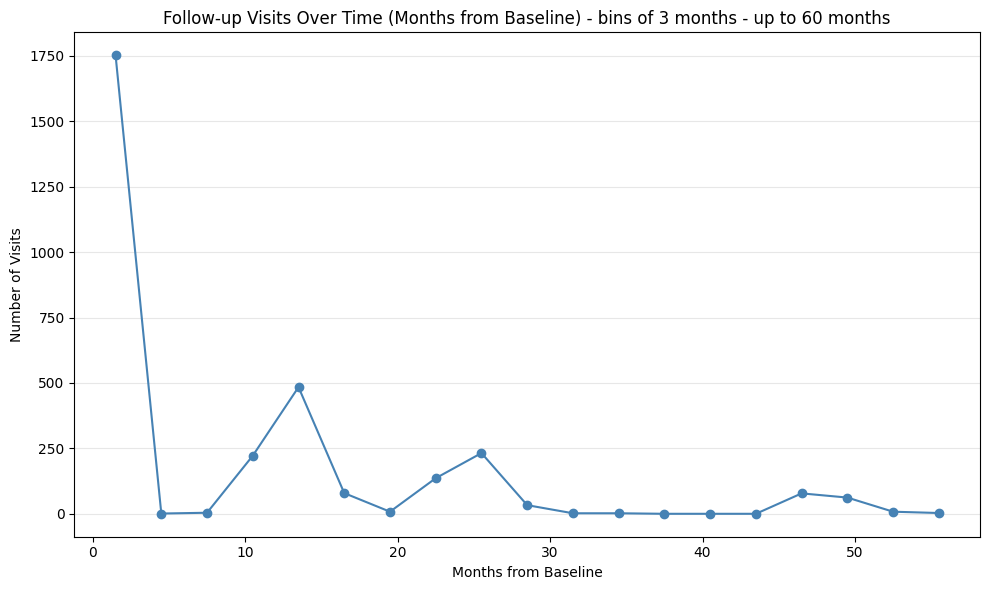

In [408]:
# Ensure datetime
visite_date_column = "visit_date"
df[visite_date_column] = pd.to_datetime(df[visite_date_column], errors="coerce")

# Keep unique patient-event pairs
df_unique = df.drop_duplicates(subset=["PATNO", "EVENT_ID"]).copy()

# 1️⃣ Baseline date per patient
baseline_dates = (
    df_unique[df_unique["EVENT_ID"] == "BL"].groupby("PATNO")[visite_date_column].min()
)
df_unique["baseline_date"] = df_unique["PATNO"].map(baseline_dates)

# 2️⃣ Time from baseline in months
df_unique["months_from_baseline"] = (
    df_unique["visit_date"] - df_unique["baseline_date"]
).dt.days / 30.44
df_unique = df_unique[df_unique["months_from_baseline"] >= 0].dropna(
    subset=["months_from_baseline"]
)

# 3️⃣ Plot as a curve
df_plot = df_unique[df_unique["months_from_baseline"] <= 60].copy()
bins = np.arange(0, df_plot["months_from_baseline"].max() + 1, 3)
counts, edges = np.histogram(df_plot["months_from_baseline"], bins=bins)

# Midpoints of bins for plotting
bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, counts, marker="o", linestyle="-", color="steelblue")
plt.title(
    "Follow-up Visits Over Time (Months from Baseline) - bins of 3 months - up to 60 months"
)
plt.xlabel("Months from Baseline")
plt.ylabel("Number of Visits")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


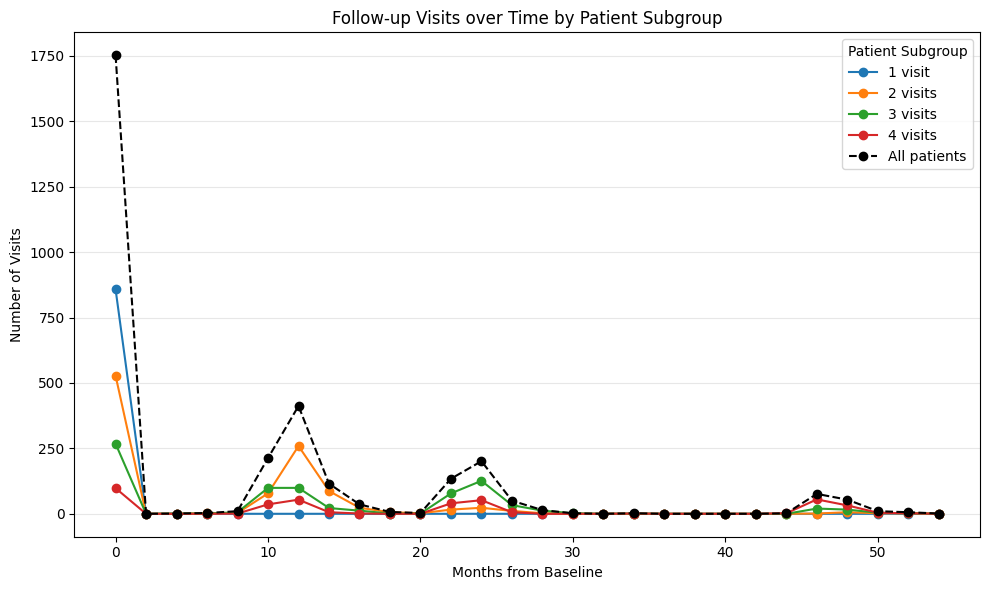

In [409]:
# Ensure datetime
df_unique = df.drop_duplicates(subset=["PATNO", "EVENT_ID"]).copy()
df_unique["visit_date"] = pd.to_datetime(df_unique["visit_date"], errors="coerce")

# Get baseline date per patient
baseline_dates = (
    df_unique[df_unique["EVENT_ID"] == "BL"].groupby("PATNO")["visit_date"].min()
)
df_unique["baseline_date"] = df_unique["PATNO"].map(baseline_dates)

# Compute months from baseline
df_unique["months_from_baseline"] = (
    df_unique["visit_date"] - df_unique["baseline_date"]
).dt.days / 30.44
df_unique = df_unique[df_unique["months_from_baseline"] >= 0]

# Compute total visits per patient
visits_per_patient = df_unique.groupby("PATNO")["EVENT_ID"].nunique()


# Assign subgroups based on total visits
def assign_visit_group(n):
    if n == 1:
        return "1 visit"
    elif n == 2:
        return "2 visits"
    elif n == 3:
        return "3 visits"
    elif n == 4:
        return "4 visits"

    else:
        return "5+ visits"


df_unique["visit_group"] = (
    df_unique["PATNO"].map(visits_per_patient).map(assign_visit_group)
)
df_plot = df_unique[df_unique["months_from_baseline"] <= 60].copy()


# Plot
plt.figure(figsize=(10, 6))
bins = np.arange(0, df_plot["months_from_baseline"].max() + 1, 2)
for group_name, group_df in df_unique.groupby("visit_group"):
    counts, bin_edges = np.histogram(group_df["months_from_baseline"], bins=bins)
    # Convert counts to cumulative or normalized fraction if desired
    plt.plot(bin_edges[:-1], counts, marker="o", label=group_name)


# Plot full population
counts_all, _ = np.histogram(df_unique["months_from_baseline"], bins=bins)
plt.plot(
    bin_edges[:-1],
    counts_all,
    marker="o",
    color="black",
    linestyle="--",
    label="All patients",
)


plt.title("Follow-up Visits over Time by Patient Subgroup")
plt.xlabel("Months from Baseline")
plt.ylabel("Number of Visits")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Patient Subgroup")
plt.tight_layout()
plt.show()


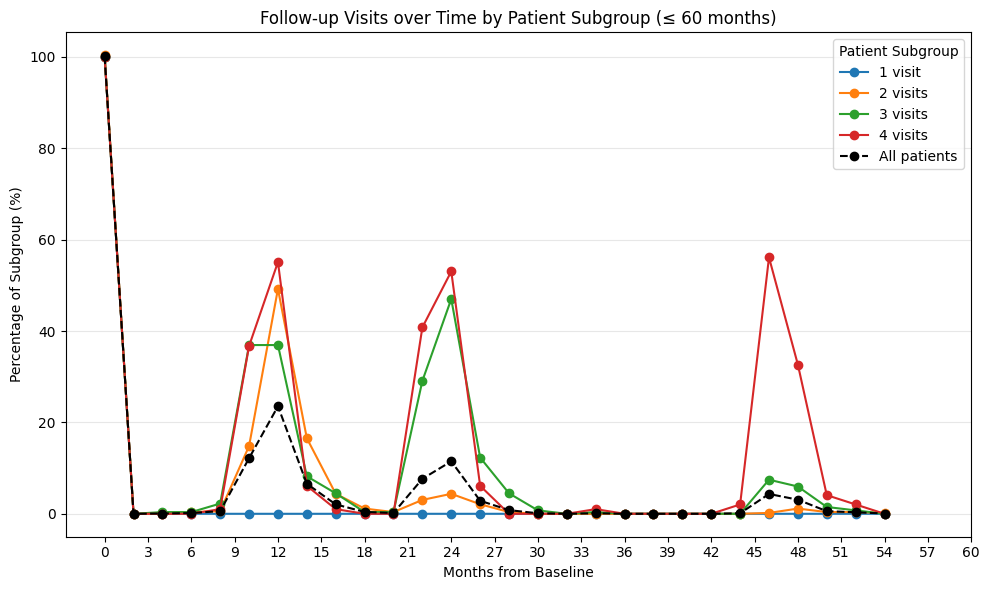

In [410]:
plt.figure(figsize=(10, 6))
bins = np.arange(0, df_plot["months_from_baseline"].max() + 1, 2)
group_name = "visit_group"
# group_name = "Research Group"
# Plot one curve per subgroup
for group_name, group_df in df_plot.groupby(group_name):
    # Get subgroup size (number of unique patients)
    n_patients = group_df["PATNO"].nunique()

    # Histogram counts
    counts, bin_edges = np.histogram(group_df["months_from_baseline"], bins=bins)

    # Convert to percentage relative to subgroup
    perc = counts / n_patients * 100

    plt.plot(bin_edges[:-1], perc, marker="o", label=group_name)

# Plot full population
total_patients = df_unique["PATNO"].nunique()
counts_all, _ = np.histogram(df_unique["months_from_baseline"], bins=bins)
perc_all = counts_all / total_patients * 100
plt.plot(
    bin_edges[:-1],
    perc_all,
    marker="o",
    color="black",
    linestyle="--",
    label="All patients",
)


plt.title("Follow-up Visits over Time by Patient Subgroup (≤ 60 months)")
plt.xlabel("Months from Baseline")
plt.ylabel("Percentage of Subgroup (%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Patient Subgroup")

# X-axis ticks every 3 months
plt.xticks(np.arange(0, 60 + 1, 3))

plt.tight_layout()
plt.show()


- Tous on une baseline
- si 2 visits, la deuxieme est surtout à +12 et parfois +24 ou +48
- si 3, 2 suivant surtout sur +12 +24
- si 4, les trois apres BL sont equitablement réparties sur +12 +24 +48
- si 5+, bonne répartition avec du +36

# Image analysis

### Basic info

In [411]:
df_image = df[df.columns.intersection(ida_df.columns)]
print("Image-related DataFrame shape:", df_image.shape)
print("Image-related DataFrame columns:", df_image.columns.tolist())

Image-related DataFrame shape: (29369, 31)
Image-related DataFrame columns: ['PATNO', 'EVENT_ID', 'Project', 'Sex', 'Weight', 'Research Group', 'Visit', 'Study Date', 'Archive Date', 'Age', 'GDSCALE Total Score', 'Modality', 'Description', 'Type', 'Imaging Protocol', 'Image ID', 'Structure', 'Laterality', 'Image Type', 'Registration', 'Tissue', 'Acquisition Plane', 'Slice Thickness', 'Matrix Z', 'Acquisition Type', 'Manufacturer', 'Mfg Model', 'Field Strength', 'Weighting', 'Description_clean', 'Advanced_Modality']


/tmp/ipykernel_64407/1467621960.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_image.select_dtypes(include=["object", "category"]).columns


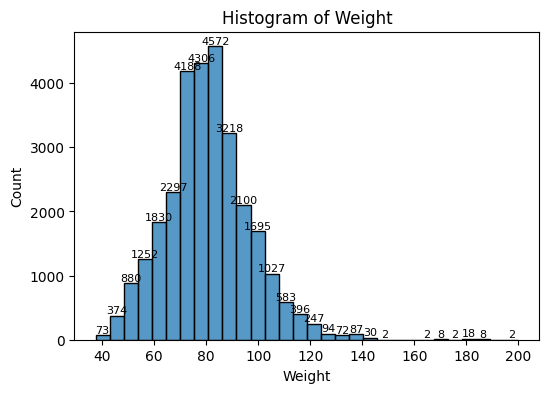

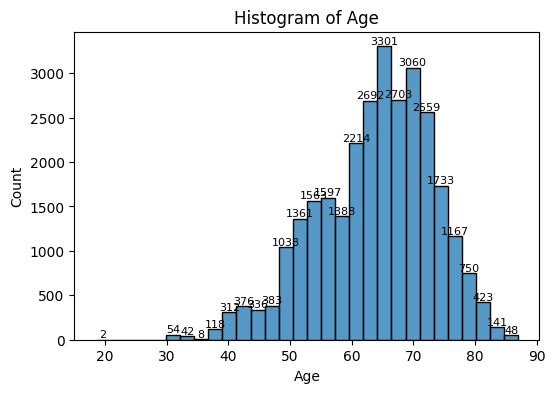

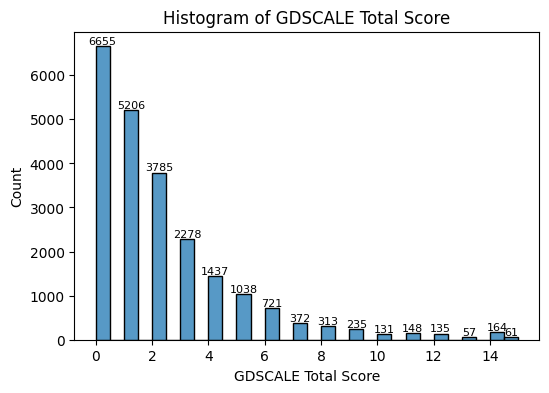

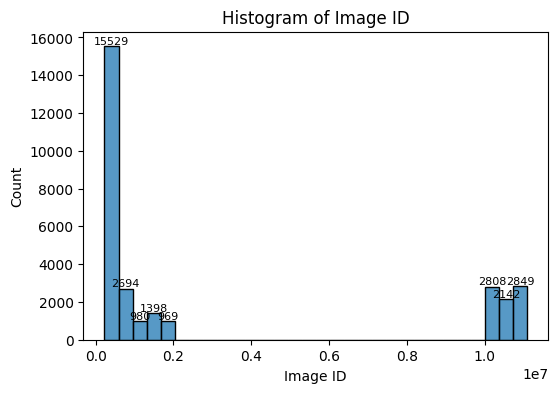

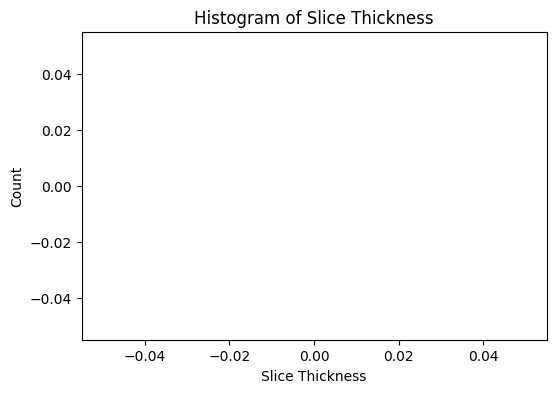

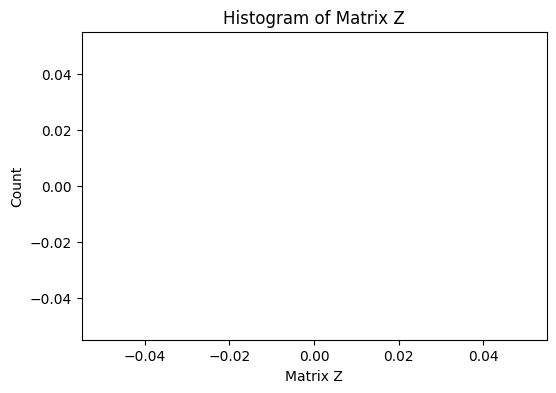

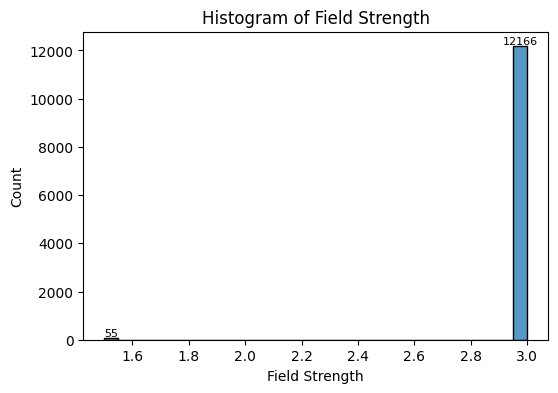

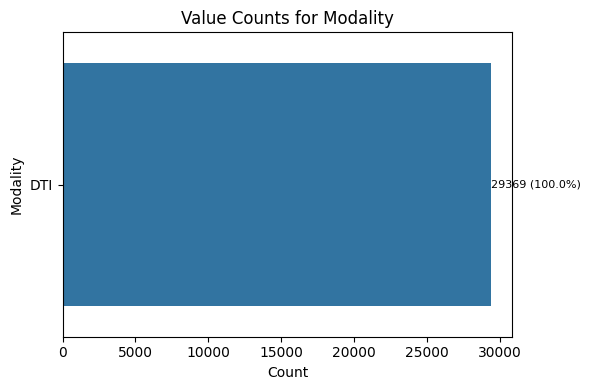

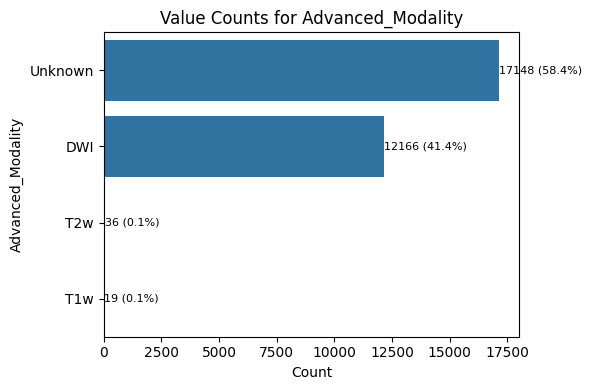

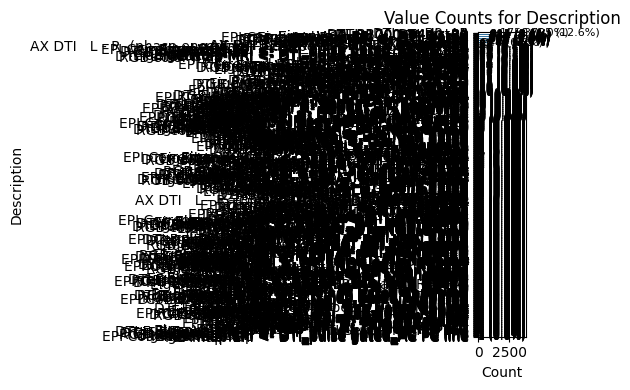

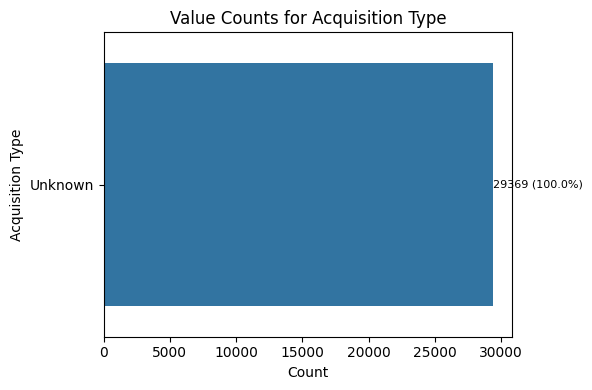

In [412]:
# Separate numeric and categorical columns
numeric_cols = df_image.select_dtypes(include=np.number).columns
categorical_cols = df_image.select_dtypes(include=["object", "category"]).columns

# -------------------------------
# Numeric Columns Histograms
# -------------------------------
for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    # Plot histogram
    ax = sns.histplot(
        df_image[col].dropna(), bins=30, kde=False
    )  # disable KDE for counts clarity

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    # Annotate counts on top of each bin
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:  # only annotate non-empty bins
            ax.text(
                patch.get_x() + patch.get_width() / 2,  # center of bin
                height + 0.5,  # slightly above the bar
                int(height),  # show integer count
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.show()

# -------------------------------
# Categorical Columns Bar Plots
# -------------------------------
categorical_cols = [
    # "Visit",
    # "Sex",
    # "Research Group",
    "Modality",
    "Advanced_Modality",
    # "Type",
    # "Structure",
    # "Laterality",
    # "Image Type",
    # "Registration",
    "Description",
    # "Tissue",
    # "Acquisition Plane",
    "Acquisition Type",
    # "Manufacturer",
    # "Mfg Model",
    # "Weighting",
]

categorical_cols = [col for col in categorical_cols if col in df_image.columns]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    df_image[col] = df_image[col].fillna("Unknown").astype(str)

    # Compute counts after cleaning
    counts = df_image[col].value_counts()
    total = counts.sum()
    order = counts.index.tolist()  # already strings

    ax = sns.countplot(y=col, data=df_image, order=order)

    for p, category in zip(ax.patches, order):
        count = counts.get(category, 0)
        percent = 100 * count / total

        ax.text(
            p.get_width() + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{count} ({percent:.1f}%)",
            va="center",
            fontsize=8,
        )

    plt.title(f"Value Counts for {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Image descriptions

In [417]:
# COunt the values of "Image Description"
print(df_image["Description"].value_counts(dropna=False).head(30))

Description
DTI_revB0_AP                          3705
DTI_gated                             1750
DTI_B700_64dir_PA                      915
DTI_B1000_64dir_PA                     915
DTI_B2000_64dir_PA                     914
DTI_B0_PA                              911
EigenVal1-EPI <- DTI_gated             834
EigenVal2-EPI <- DTI_gated             834
EigenVal0-EPI <- DTI_gated             834
EigenVectors-EPI <- DTI_gated          834
EPI Corrected B0 map <- DTI_gated      834
FA map-EPI <- DTI_gated                834
MD map-EPI <- DTI_gated                833
RGB color map-EPI <- DTI_gated         833
DTI Full Tensors-EPI <- DTI_gated      833
4D DWI <- DTI_gated                    832
RGB color map-MRI <- DTI_gated         756
DTI Full Tensors-MRI <- DTI_gated      756
EigenVal1-MRI <- DTI_gated             756
FA map-MRI <- DTI_gated                756
MD map-MRI <- DTI_gated                756
EigenVal0-MRI <- DTI_gated             756
EigenVal2-MRI <- DTI_gated             755

### Simultaneous Multimodal Availability (Per Visit)

In [414]:
# Unique subject-visit-modality combinations
visit_modalities = (
    df.groupby(["PATNO", "EVENT_ID"])["Advanced_Modality"].unique().reset_index()
)

visit_modalities["n_modalities"] = visit_modalities["Advanced_Modality"].apply(len)
print(visit_modalities["n_modalities"].value_counts().to_frame().T)
print(visit_modalities["n_modalities"].describe().to_frame().T)


n_modalities     1    2
count         2532  861
               count      mean       std  min  25%  50%  75%  max
n_modalities  3393.0  1.253758  0.435225  1.0  1.0  1.0  2.0  2.0


In [415]:
# Pivot to binary presence matrix
visit_modality_matrix = (
    df.assign(present=1)
    .drop_duplicates(["PATNO", "EVENT_ID", "Advanced_Modality"])
    .pivot_table(
        index=["PATNO", "EVENT_ID"],
        columns="Advanced_Modality",
        values="present",
        fill_value=0,
    )
)
co_occurrence = visit_modality_matrix.T @ visit_modality_matrix
print(co_occurrence)

Advanced_Modality     DWI   T1w   T2w  Unknown
Advanced_Modality                             
DWI                3375.0   0.0   0.0    848.0
T1w                   0.0  15.0  13.0      0.0
T2w                   0.0  13.0  13.0      0.0
Unknown             848.0   0.0   0.0    851.0


# Image IDs
Should be useful to download the data

In [416]:
image_ids = (
    df["Image ID"]
    .dropna()  # remove NaNs
    .apply(
        lambda x: str(int(x)) if isinstance(x, float) else str(x).strip()
    )  # float → int → str, else str
    .unique()
    .tolist()
)

print(f"Unique Image IDs: {len(image_ids)}")
print(",".join(image_ids))


Unique Image IDs: 29369
10955684,1526371,1526372,1526369,1548626,1548627,1526387,1526388,1526383,1530149,1530150,1692870,1692871,1692872,1692873,1692874,1692875,1692876,1692877,1525734,1692883,1692884,1692885,1692886,1692887,1692888,1692889,1692890,1525547,1525548,1561315,1561316,1497588,1497589,1700990,1700991,1700992,1700993,1700994,1700995,1700996,1700997,1642211,1642212,1642213,1642214,1642215,1642216,1642217,1642218,11081637,11081638,11081639,11081640,11081641,11081642,11081643,11081644,11058856,11058857,11058858,11058859,11058860,11058861,11058862,11058863,1652922,1652923,1652924,1652925,1652926,1652927,1652928,1652929,10317176,10317177,10317178,10317179,10317180,10317181,10317182,10317183,1497600,1497601,1583893,1583894,1719496,1719497,1719498,1719499,1719500,1719501,1719502,1719503,1497612,1497613,1609342,1609343,10283949,10283950,10283951,10283952,10283953,10283954,10283955,10283956,1491222,1491223,1581255,1581256,1493040,1493041,1571506,1571507,1704606,1704611,1622598,1622599